## Bibliotecas

In [1]:
from ultralytics import YOLO
from IPython.display import Image, display
import matplotlib.pyplot as plt
import ultralytics
import os
import glob
import random
import shutil
import yaml

ultralytics.checks()

Ultralytics 8.4.60 🚀 Python-3.10.20 torch-2.10.0 CUDA:0 (NVIDIA GB10, 122501MiB)


Setup complete ✅ (20 CPUs, 119.6 GB RAM, 993.1/3666.0 GB disk)


## Split do Dataset

In [2]:
def build_physical_subset(
    original_yaml_path: str,
    output_dir: str,
    n_train: int = 1000,
    n_val: int = 150,
    n_test: int = 300,
    seed: int = 42
) -> str:
    random.seed(seed)

    with open(original_yaml_path) as f:
        cfg = yaml.safe_load(f)

    base_path = cfg['path']
    splits = {'train': n_train, 'val': n_val, 'test': n_test}
    
    new_dataset_dir = os.path.join(output_dir, 'dataset_subset')
    os.makedirs(new_dataset_dir, exist_ok=True)
    
    valid_extensions = ('.jpg', '.jpeg', '.png')

    for split, n in splits.items():
        img_dir = os.path.join(base_path, 'images', split)
        all_files = os.listdir(img_dir)
        
        all_images = [f for f in all_files if f.lower().endswith(valid_extensions)]
        
        valid_pairs = []
        for img_name in all_images:
            img_path = os.path.join(img_dir, img_name)
            
            label_name = img_name.rsplit('.', 1)[0] + '.txt'
            label_path = os.path.join(base_path, 'labels', split, label_name)
            
            if os.path.exists(label_path):
                valid_pairs.append((img_path, label_path))

        if len(valid_pairs) < n:
            raise ValueError(f"[{split}] Apenas {len(valid_pairs)} pares válidos encontrados. Precisava de {n}.")

        selected_pairs = random.sample(valid_pairs, n)

        dest_img_dir = os.path.join(new_dataset_dir, 'images', split)
        dest_lbl_dir = os.path.join(new_dataset_dir, 'labels', split)
        os.makedirs(dest_img_dir, exist_ok=True)
        os.makedirs(dest_lbl_dir, exist_ok=True)

        for img_src, lbl_src in selected_pairs:
            shutil.copy2(img_src, dest_img_dir)
            shutil.copy2(lbl_src, dest_lbl_dir)

        print(f"[{split}] {n} imagens e anotações copiadas para -> {dest_img_dir}")

    new_cfg = {
        'path': new_dataset_dir,
        'train': 'images/train',
        'val':   'images/val',
        'test':  'images/test',
        'names': cfg['names']
    }

    new_yaml_path = os.path.join(output_dir, 'dangerousItems_subset.yaml')
    with open(new_yaml_path, 'w') as f:
        yaml.dump(new_cfg, f, default_flow_style=False, allow_unicode=True)

    print(f"\nYML gerado: {new_yaml_path}")
    return new_yaml_path

## YOLO26

In [3]:
class Yolo26():

    def __init__(self):
        pass

    def set_model(self, model_name: str):
        return YOLO(model_name)

    def train(self, model, save_path: str, yaml_path: str,
              epochs: int = 100, patience: int = 20,
              freeze: int = 10, lr: float = 1e-3, save: bool = True):
        """Treina o modelo com base no yaml"""
        return model.train(
            data=yaml_path,
            epochs=epochs,
            patience=patience,
            freeze=freeze,
            lr0=lr,
            save=save,
            project=save_path,
            optimizer='Adam',
            imgsz=640,
            batch=32,
            cos_lr=True,
            close_mosaic=15,
            cache='disk',
        )

    def get_best_model_path(self, train_results) -> str:
        """Retorna o caminho do melhor modelo salvo após o treino"""
        return os.path.join(str(train_results.save_dir), 'weights', 'best.pt')

    def val(self, best_model_path: str):
        """Valida o melhor modelo treinado no conjunto de validação"""
        model = YOLO(best_model_path)
        return model.val()
    
    def test(self, best_model_path: str, yaml_path: str):
        """Avalia o melhor modelo treinado no conjunto de teste"""
        model = YOLO(best_model_path)
        return model.val(data=yaml_path, split='test')

    def predict(self, best_model_path: str, test_path: str):
        """Realiza predição com o melhor modelo treinado"""
        model = YOLO(best_model_path)
        return model(test_path)

## Setup

In [4]:
root = os.getcwd()
results_dir = os.path.join(root, 'resultados')
os.makedirs(results_dir, exist_ok=True)

model_paths = {
    'nano': {
        'train': os.path.join(results_dir, 'train', 'nano'),
        'val': os.path.join(results_dir, 'val',   'nano'),
        'test': os.path.join(results_dir, 'test',  'nano'),
    },
    'small': {
        'train': os.path.join(results_dir, 'train', 'small'),
        'val': os.path.join(results_dir, 'val',   'small'),
        'test': os.path.join(results_dir, 'test',  'small'),
    },
}

subset_yaml = build_physical_subset(
    original_yaml_path='dangerousItems.yaml',
    output_dir=results_dir,
    n_train=1000,
    n_val=150,
    n_test=300,
    seed=42
)

yolo26 = Yolo26()

[train] 1000 imagens e anotações copiadas para -> /opt/topicos/dangerousItems/yolo_dangerous_items/resultados/dataset_subset/images/train
[val] 150 imagens e anotações copiadas para -> /opt/topicos/dangerousItems/yolo_dangerous_items/resultados/dataset_subset/images/val


[test] 300 imagens e anotações copiadas para -> /opt/topicos/dangerousItems/yolo_dangerous_items/resultados/dataset_subset/images/test

YML gerado: /opt/topicos/dangerousItems/yolo_dangerous_items/resultados/dangerousItems_subset.yaml


## Nano

### Treinamento

In [5]:
model_nano = yolo26.set_model('yolo26n.pt')

results_train_nano = yolo26.train(
    model_nano,
    save_path=model_paths['nano']['train'],
    yaml_path=subset_yaml
)

best_nano = yolo26.get_best_model_path(results_train_nano)
print(f"Melhor modelo nano: {best_nano}")

New https://pypi.org/project/ultralytics/8.4.64 available 😃 Update with 'pip install -U ultralytics'


Ultralytics 8.4.60 🚀 Python-3.10.20 torch-2.10.0 CUDA:0 (NVIDIA GB10, 122501MiB)


engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/opt/topicos/dangerousItems/yolo_dangerous_items/resultados/dangerousItems_subset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patience=20, perspective=0.0, plots=Tru

Overriding model.yaml nc=80 with nc=5



                   from  n    params  module                                       arguments                     


...

                 rifle         33         35      0.838      0.686      0.747      0.427


                   gun         25         28      0.763      0.714      0.743      0.418


Speed: 0.1ms preprocess, 1.3ms inference, 0.0ms loss, 0.0ms postprocess per image


Results saved to /opt/topicos/dangerousItems/yolo_dangerous_items/resultados/train/nano/train-2


Melhor modelo nano: /opt/topicos/dangerousItems/yolo_dangerous_items/resultados/train/nano/train-2/weights/best.pt


### Validação

In [6]:
metrics_nano = yolo26.val(best_nano)

print(f"\n[Nano] mAP@50: {metrics_nano.box.map50:.4f}")
print(f"[Nano] mAP@50-95: {metrics_nano.box.map:.4f}")
print(f"[Nano] Precision: {metrics_nano.box.mp:.4f}")
print(f"[Nano] Recall: {metrics_nano.box.mr:.4f}")

Ultralytics 8.4.60 🚀 Python-3.10.20 torch-2.10.0 CUDA:0 (NVIDIA GB10, 122501MiB)


YOLO26n summary (fused): 122 layers, 2,375,811 parameters, 0 gradients


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5164.8±1210.1 MB/s, size: 91.4 KB)


val: Scanning /opt/topicos/dangerousItems/yolo_dangerous_items/resultados/dataset_subset/labels/val.cache... 150 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 44.9Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 10% ━─────────── 1/10 1.6it/s 0.2s<5.6s

...

                 rifle         33         35      0.956      0.615      0.744      0.419


                   gun         25         28      0.873      0.643      0.735      0.428


Speed: 1.2ms preprocess, 2.9ms inference, 0.0ms loss, 0.0ms postprocess per image


Results saved to /opt/topicos/dangerousItems/yolo_dangerous_items/runs/detect/val-3



[Nano] mAP@50: 0.6478
[Nano] mAP@50-95: 0.4101
[Nano] Precision: 0.8017
[Nano] Recall: 0.5592


### Teste

In [7]:
metrics_test_nano = yolo26.test(
    best_model_path=best_nano, 
    yaml_path=subset_yaml
)

print(f"\n[Nano TESTE] mAP@50: {metrics_test_nano.box.map50:.4f}")
print(f"[Nano TESTE] mAP@50-95: {metrics_test_nano.box.map:.4f}")

Ultralytics 8.4.60 🚀 Python-3.10.20 torch-2.10.0 CUDA:0 (NVIDIA GB10, 122501MiB)


YOLO26n summary (fused): 122 layers, 2,375,811 parameters, 0 gradients


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5975.6±1799.1 MB/s, size: 85.7 KB)


val: Scanning /opt/topicos/dangerousItems/yolo_dangerous_items/resultados/dataset_subset/labels/test.cache... 300 images, 26 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 89.9Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 5% ╸─────────── 1/19 1.7it/s 0.2s<10.5s

...

                 rifle         47         48      0.731       0.75      0.781      0.469


                   gun         62         69      0.878      0.565       0.64      0.286


Speed: 1.0ms preprocess, 2.6ms inference, 0.0ms loss, 0.0ms postprocess per image


Results saved to /opt/topicos/dangerousItems/yolo_dangerous_items/runs/detect/val-4



[Nano TESTE] mAP@50: 0.6658
[Nano TESTE] mAP@50-95: 0.4163


### Gráficos

In [8]:
nano_dir = results_train_nano.save_dir

#### Resultados do Teste

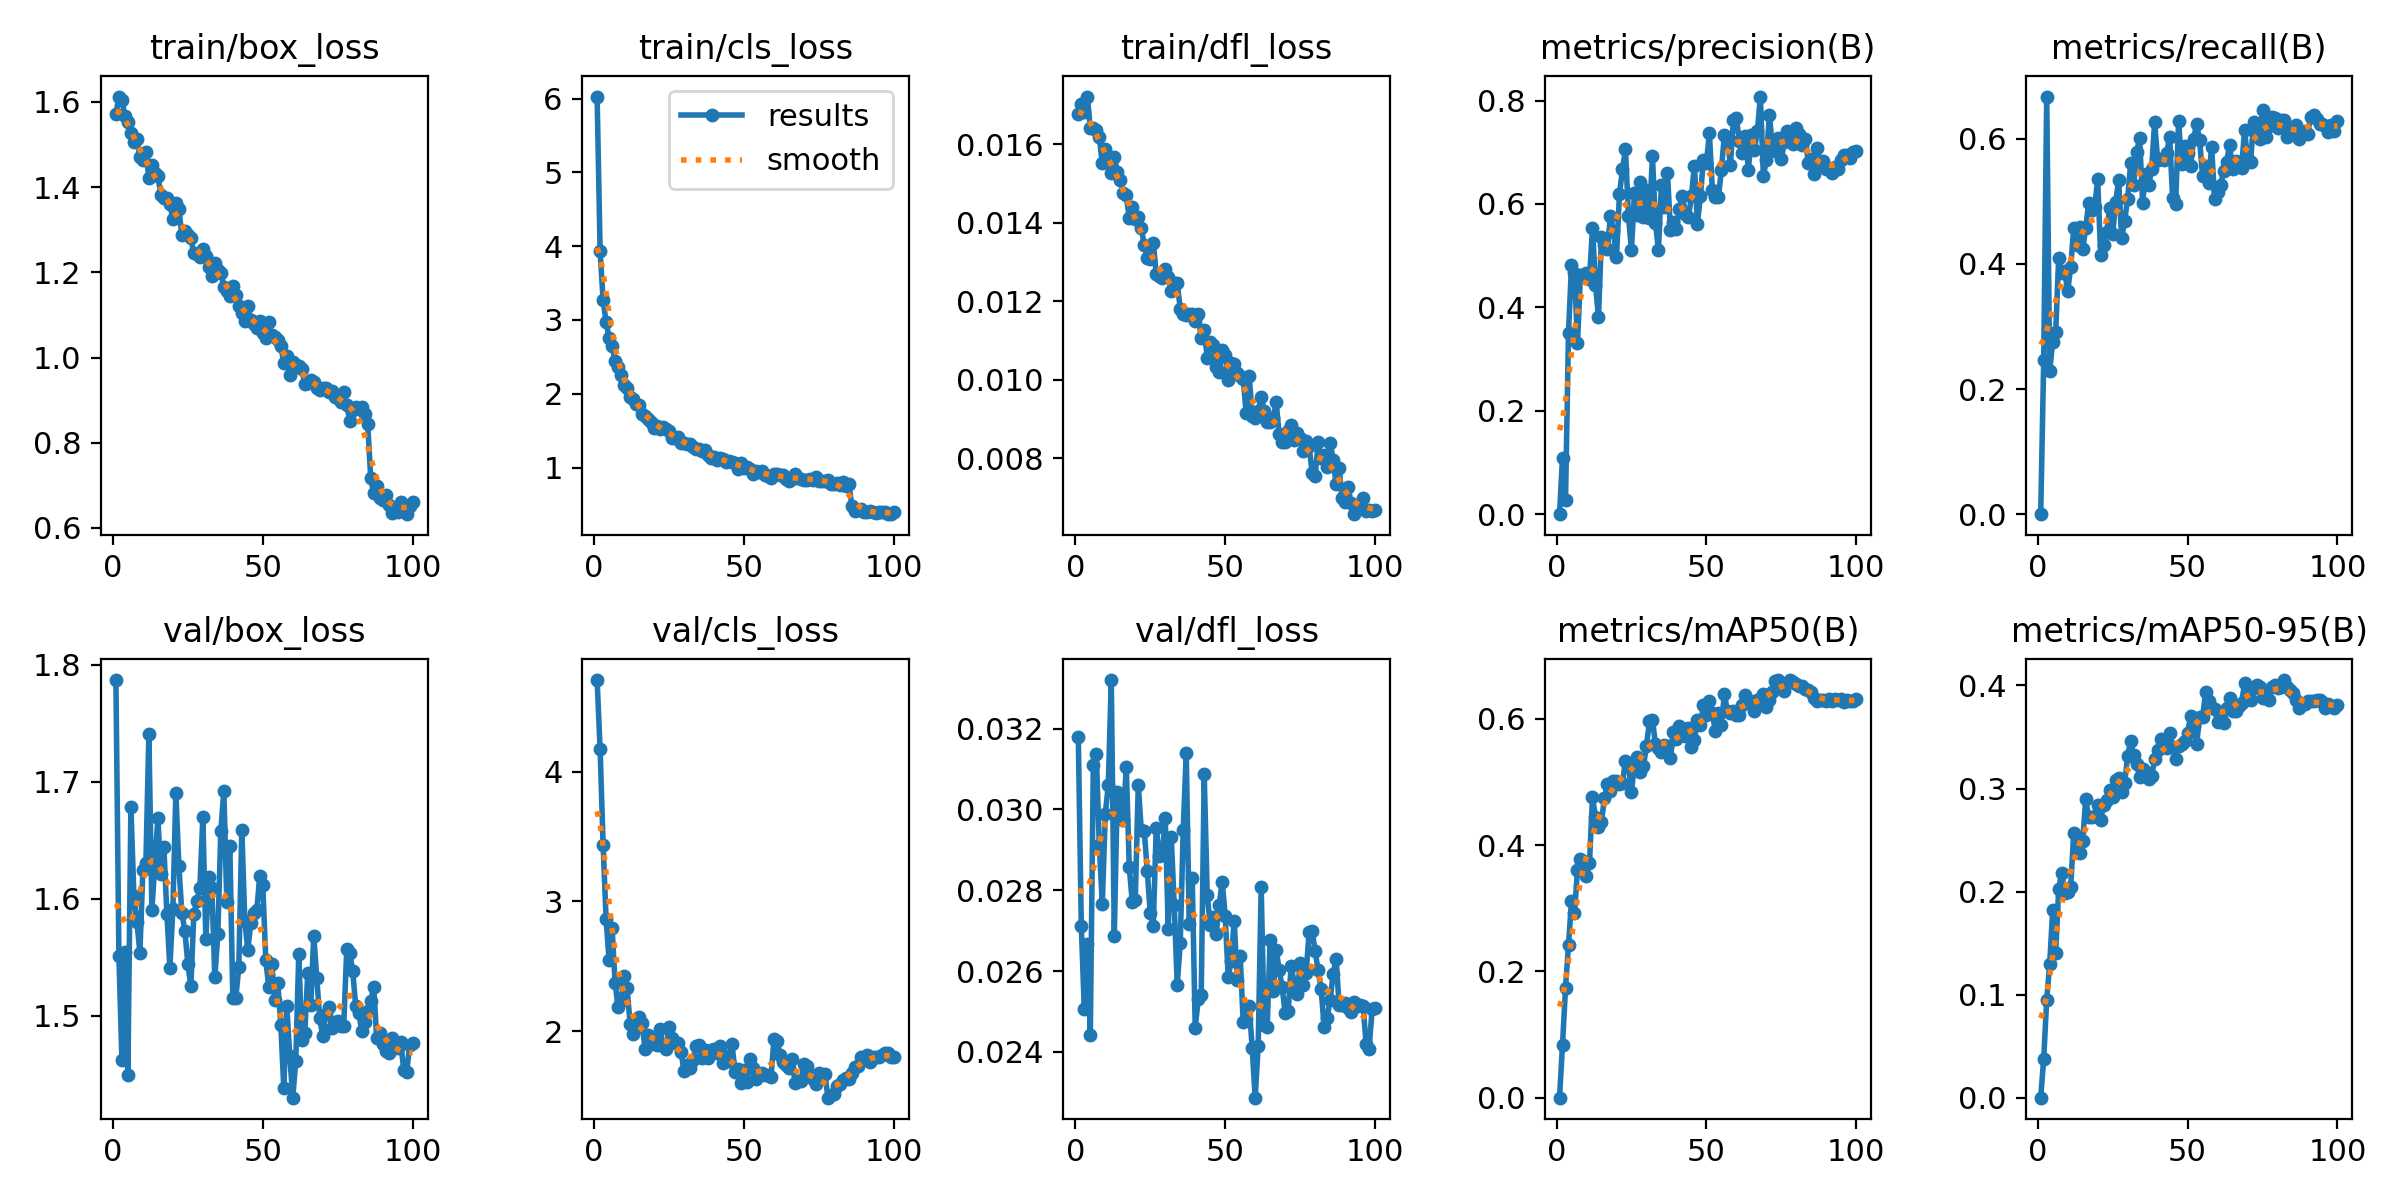

In [9]:
display(Image(filename=os.path.join(nano_dir, 'results.png'), width=850))

#### Matriz de Confusão

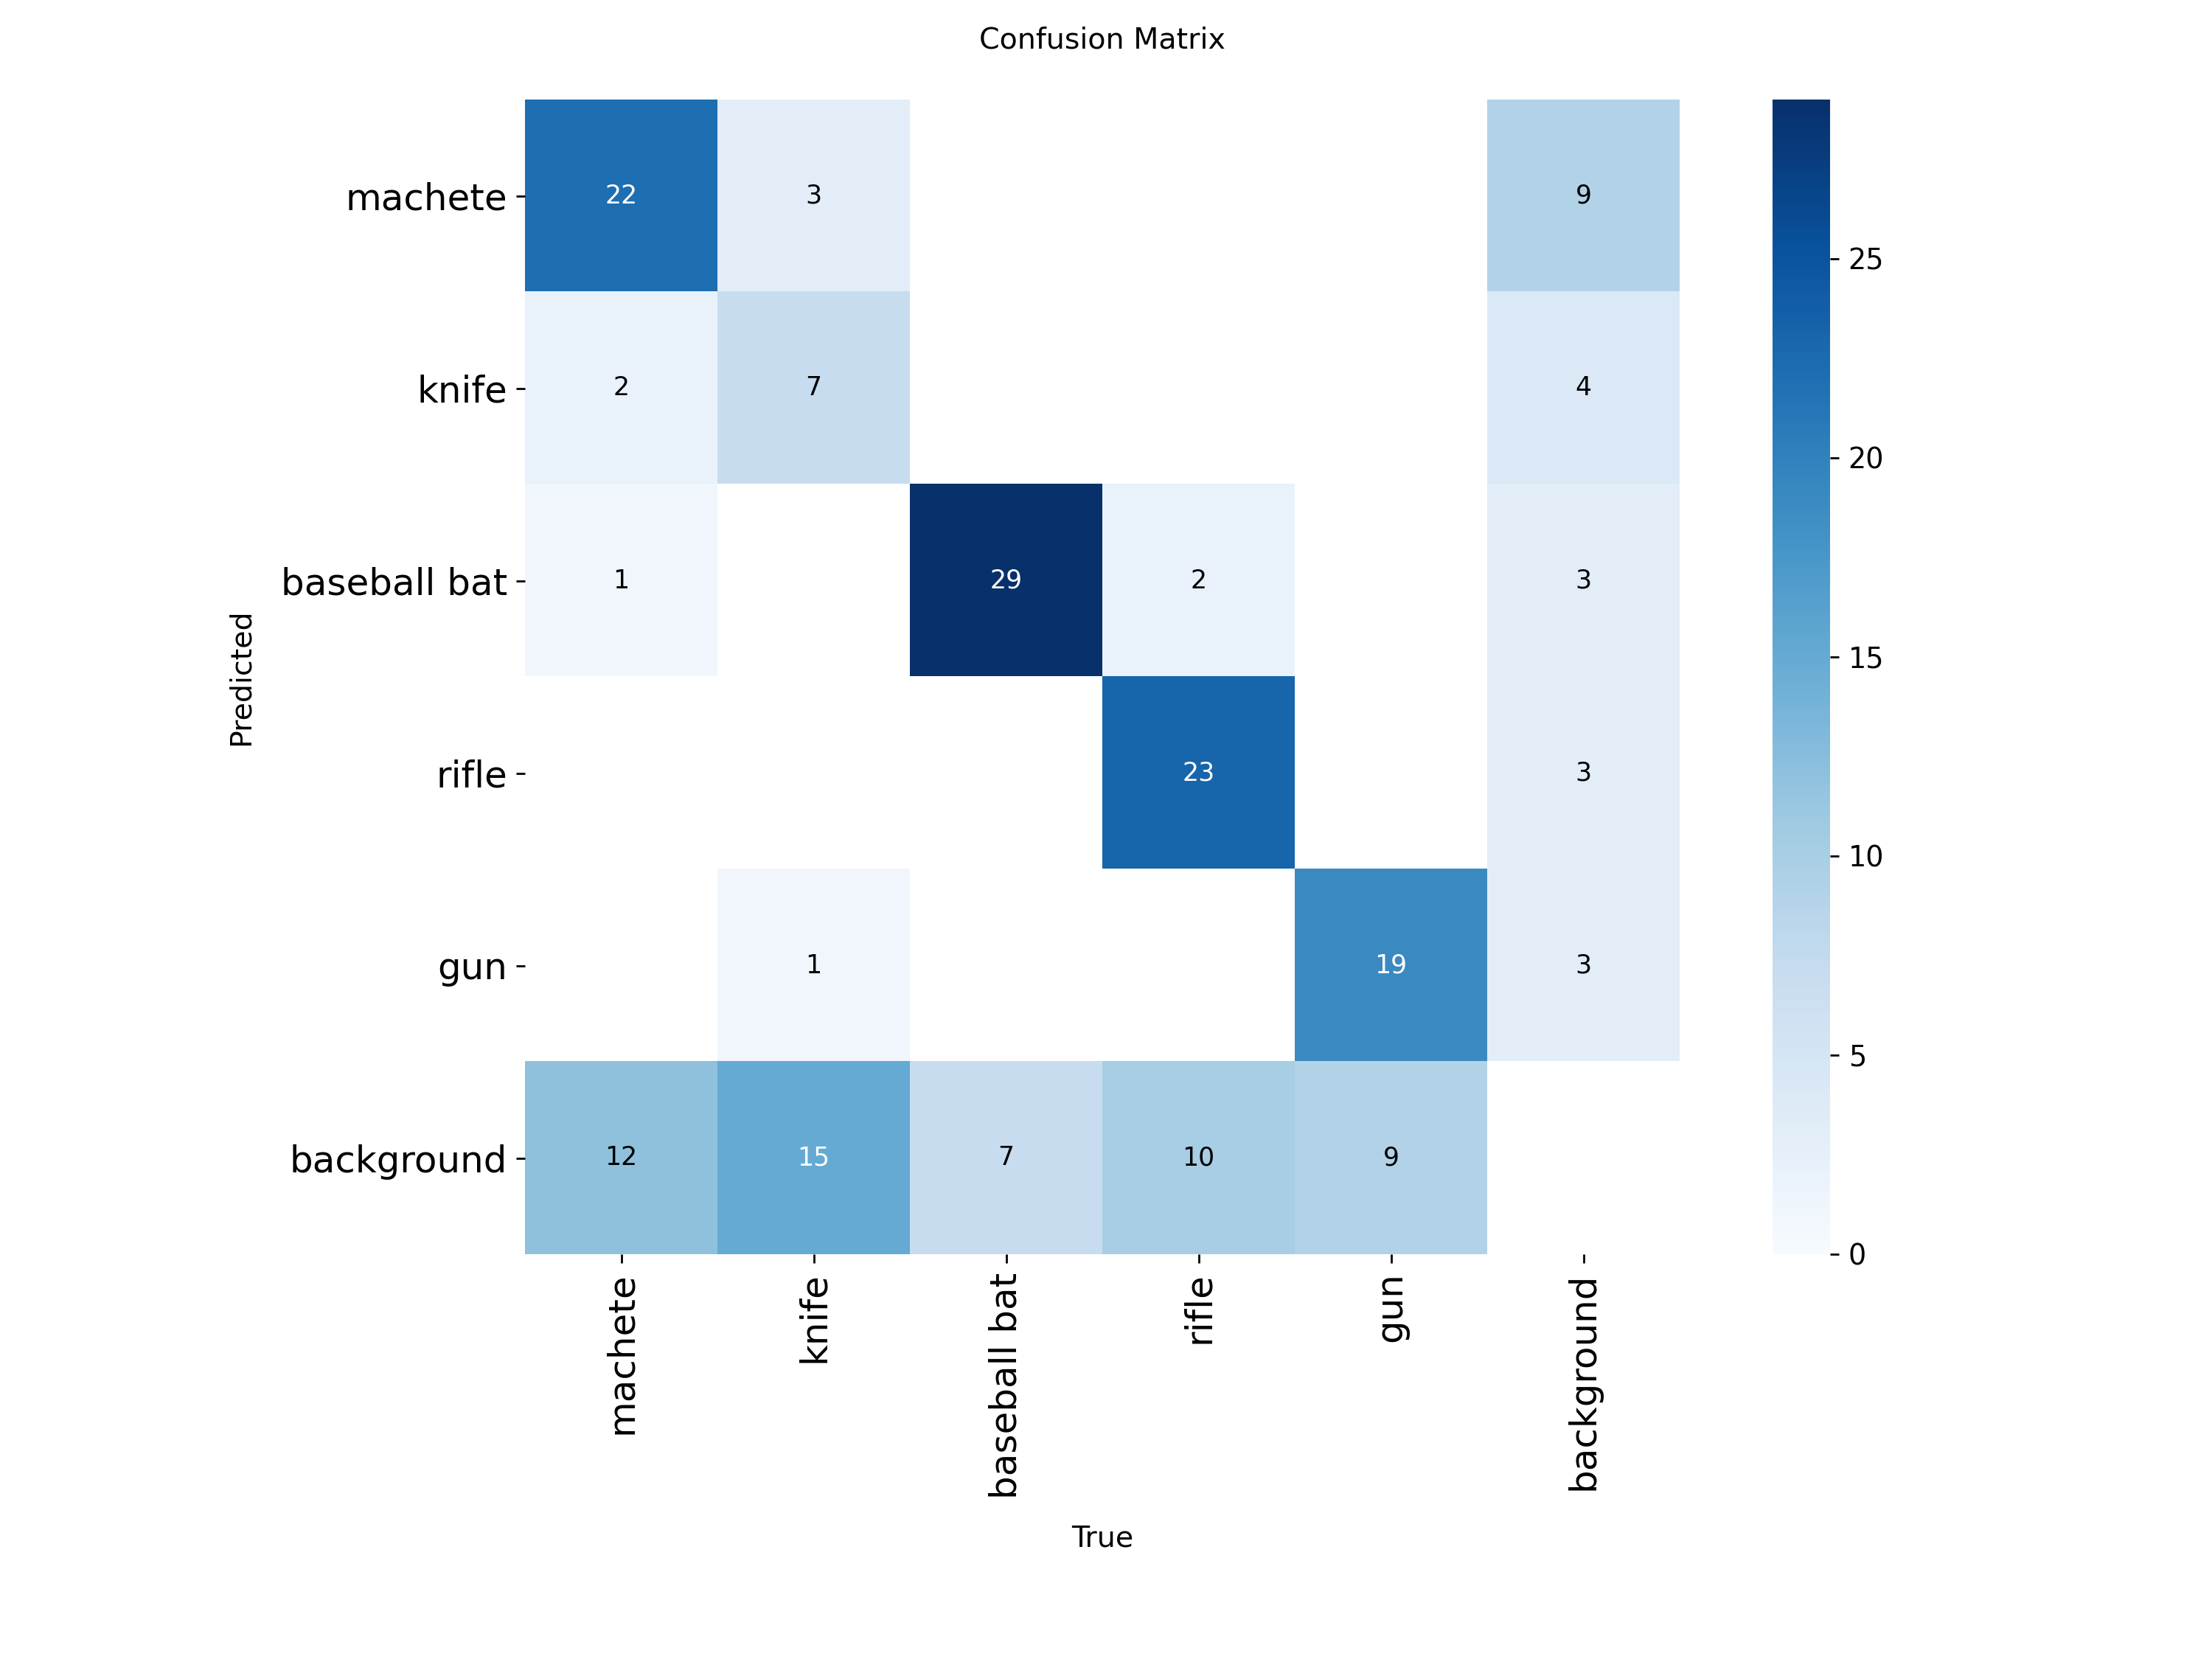

In [10]:
display(Image(filename=os.path.join(nano_dir, 'confusion_matrix.png'), width=800))

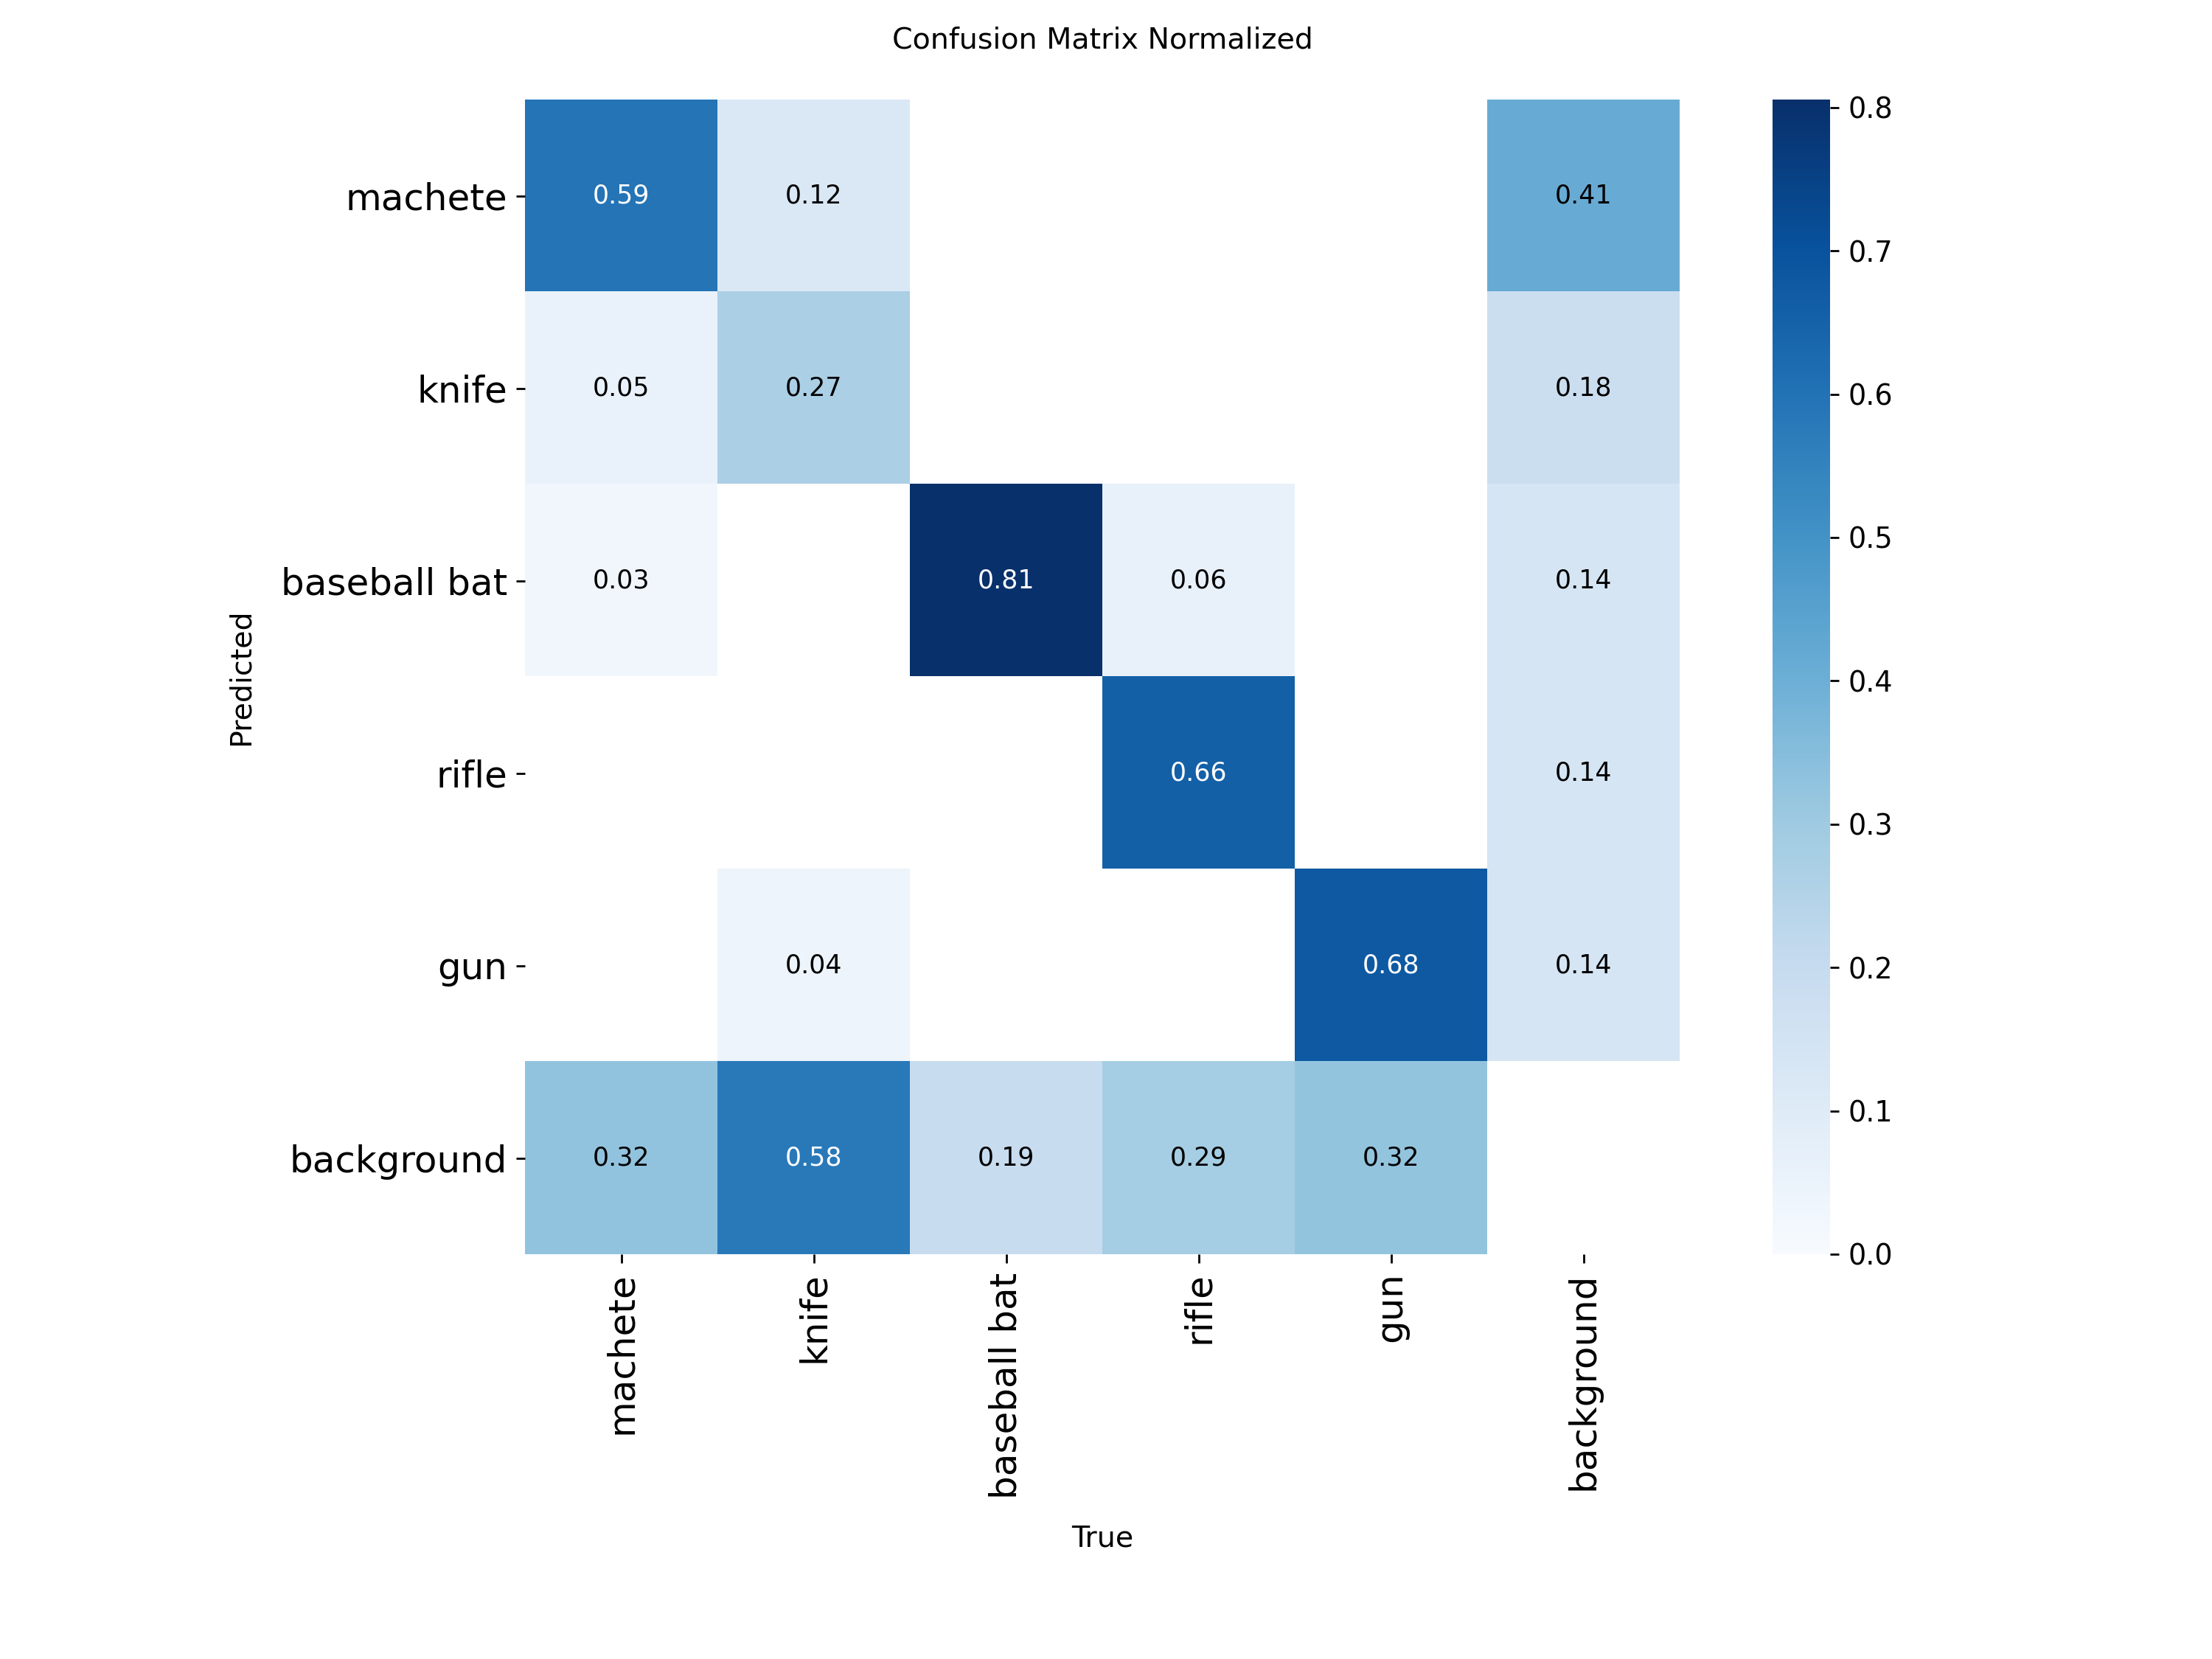

In [11]:
display(Image(filename=os.path.join(nano_dir, 'confusion_matrix_normalized.png'), width=800))

### Curva Precision-Recall

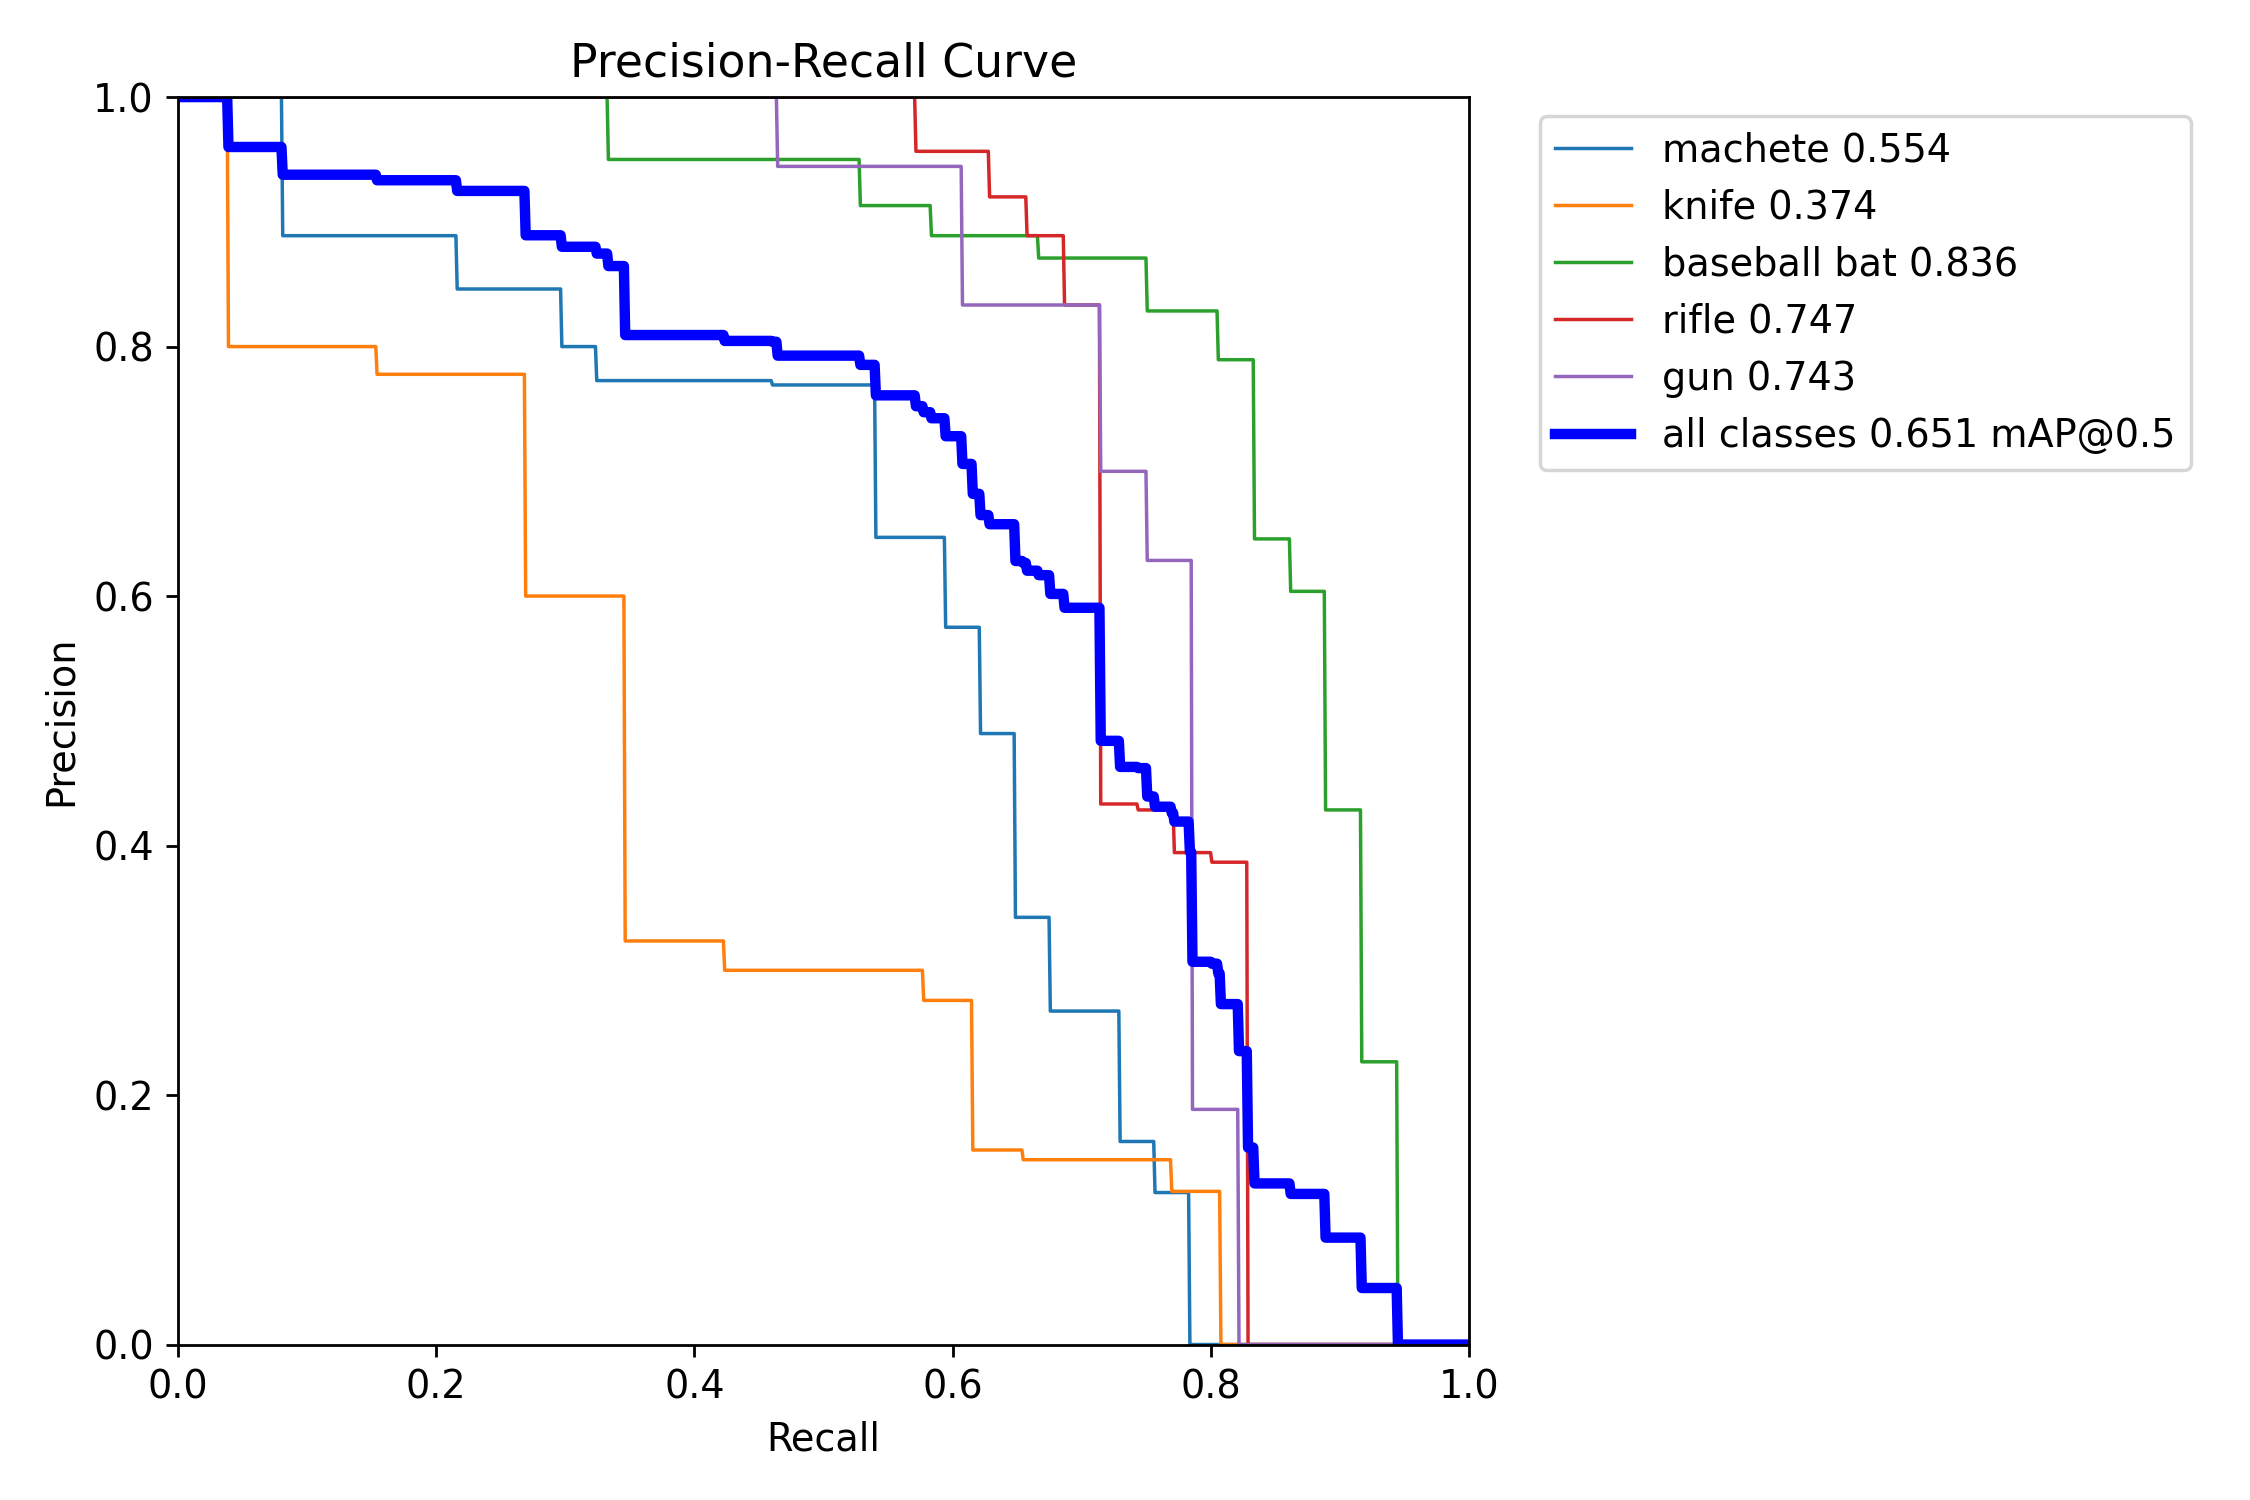

In [12]:
display(Image(filename=os.path.join(nano_dir, 'BoxPR_curve.png'), width=800))

## Small

### Treinamento

In [13]:
model_small = yolo26.set_model('yolo26s.pt')

results_train_small = yolo26.train(
    model=model_small,
    save_path=model_paths['small']['train'],
    yaml_path=subset_yaml
)

best_small = yolo26.get_best_model_path(results_train_small)
print(f"Melhor modelo small: {best_small}")

New https://pypi.org/project/ultralytics/8.4.64 available 😃 Update with 'pip install -U ultralytics'


Ultralytics 8.4.60 🚀 Python-3.10.20 torch-2.10.0 CUDA:0 (NVIDIA GB10, 122501MiB)


engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/opt/topicos/dangerousItems/yolo_dangerous_items/resultados/dangerousItems_subset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patience=20, perspective=0.0, plots=True,

Overriding model.yaml nc=80 with nc=5



                   from  n    params  module                                       arguments                     


...

                 rifle         33         35      0.922      0.629      0.794      0.417


                   gun         25         28      0.819      0.714      0.748      0.465


Speed: 0.2ms preprocess, 2.6ms inference, 0.0ms loss, 0.0ms postprocess per image


Results saved to /opt/topicos/dangerousItems/yolo_dangerous_items/resultados/train/small/train


Melhor modelo small: /opt/topicos/dangerousItems/yolo_dangerous_items/resultados/train/small/train/weights/best.pt


### Validação

In [14]:
metrics_small = yolo26.val(best_small)

print(f"\n[Small] mAP@50: {metrics_small.box.map50:.4f}")
print(f"[Small] mAP@50-95: {metrics_small.box.map:.4f}")
print(f"[Small] Precision: {metrics_small.box.mp:.4f}")
print(f"[Small] Recall: {metrics_small.box.mr:.4f}")

Ultralytics 8.4.60 🚀 Python-3.10.20 torch-2.10.0 CUDA:0 (NVIDIA GB10, 122501MiB)


YOLO26s summary (fused): 122 layers, 9,467,115 parameters, 0 gradients


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6108.1±990.0 MB/s, size: 91.4 KB)


val: Scanning /opt/topicos/dangerousItems/yolo_dangerous_items/resultados/dataset_subset/labels/val.cache... 150 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 44.9Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 10% ━─────────── 1/10 2.3it/s 0.1s<3.9s

...

                 rifle         33         35       0.96      0.679      0.763      0.416


                   gun         25         28      0.823      0.679      0.744      0.414


Speed: 1.1ms preprocess, 6.4ms inference, 0.0ms loss, 0.0ms postprocess per image


Results saved to /opt/topicos/dangerousItems/yolo_dangerous_items/runs/detect/val-5



[Small] mAP@50: 0.7071
[Small] mAP@50-95: 0.4353
[Small] Precision: 0.8317
[Small] Recall: 0.6257


### Teste

In [15]:
metrics_test_small = yolo26.test(
    best_model_path=best_small, 
    yaml_path=subset_yaml
)

print(f"\n[Small TESTE] mAP@50: {metrics_test_small.box.map50:.4f}")
print(f"[Small TESTE] mAP@50-95: {metrics_test_small.box.map:.4f}")

Ultralytics 8.4.60 🚀 Python-3.10.20 torch-2.10.0 CUDA:0 (NVIDIA GB10, 122501MiB)


YOLO26s summary (fused): 122 layers, 9,467,115 parameters, 0 gradients


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6571.2±1668.4 MB/s, size: 85.7 KB)


val: Scanning /opt/topicos/dangerousItems/yolo_dangerous_items/resultados/dataset_subset/labels/test.cache... 300 images, 26 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 96.8Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 5% ╸─────────── 1/19 1.4it/s 0.2s<12.9s

...

                 rifle         47         48      0.815      0.875      0.899      0.599


                   gun         62         69      0.862      0.635      0.707      0.302


Speed: 0.4ms preprocess, 5.0ms inference, 0.0ms loss, 0.0ms postprocess per image


Results saved to /opt/topicos/dangerousItems/yolo_dangerous_items/runs/detect/val-6



[Small TESTE] mAP@50: 0.7449
[Small TESTE] mAP@50-95: 0.4719


### Gráficos

In [16]:
small_dir = results_train_small.save_dir

#### Resultados do Treino

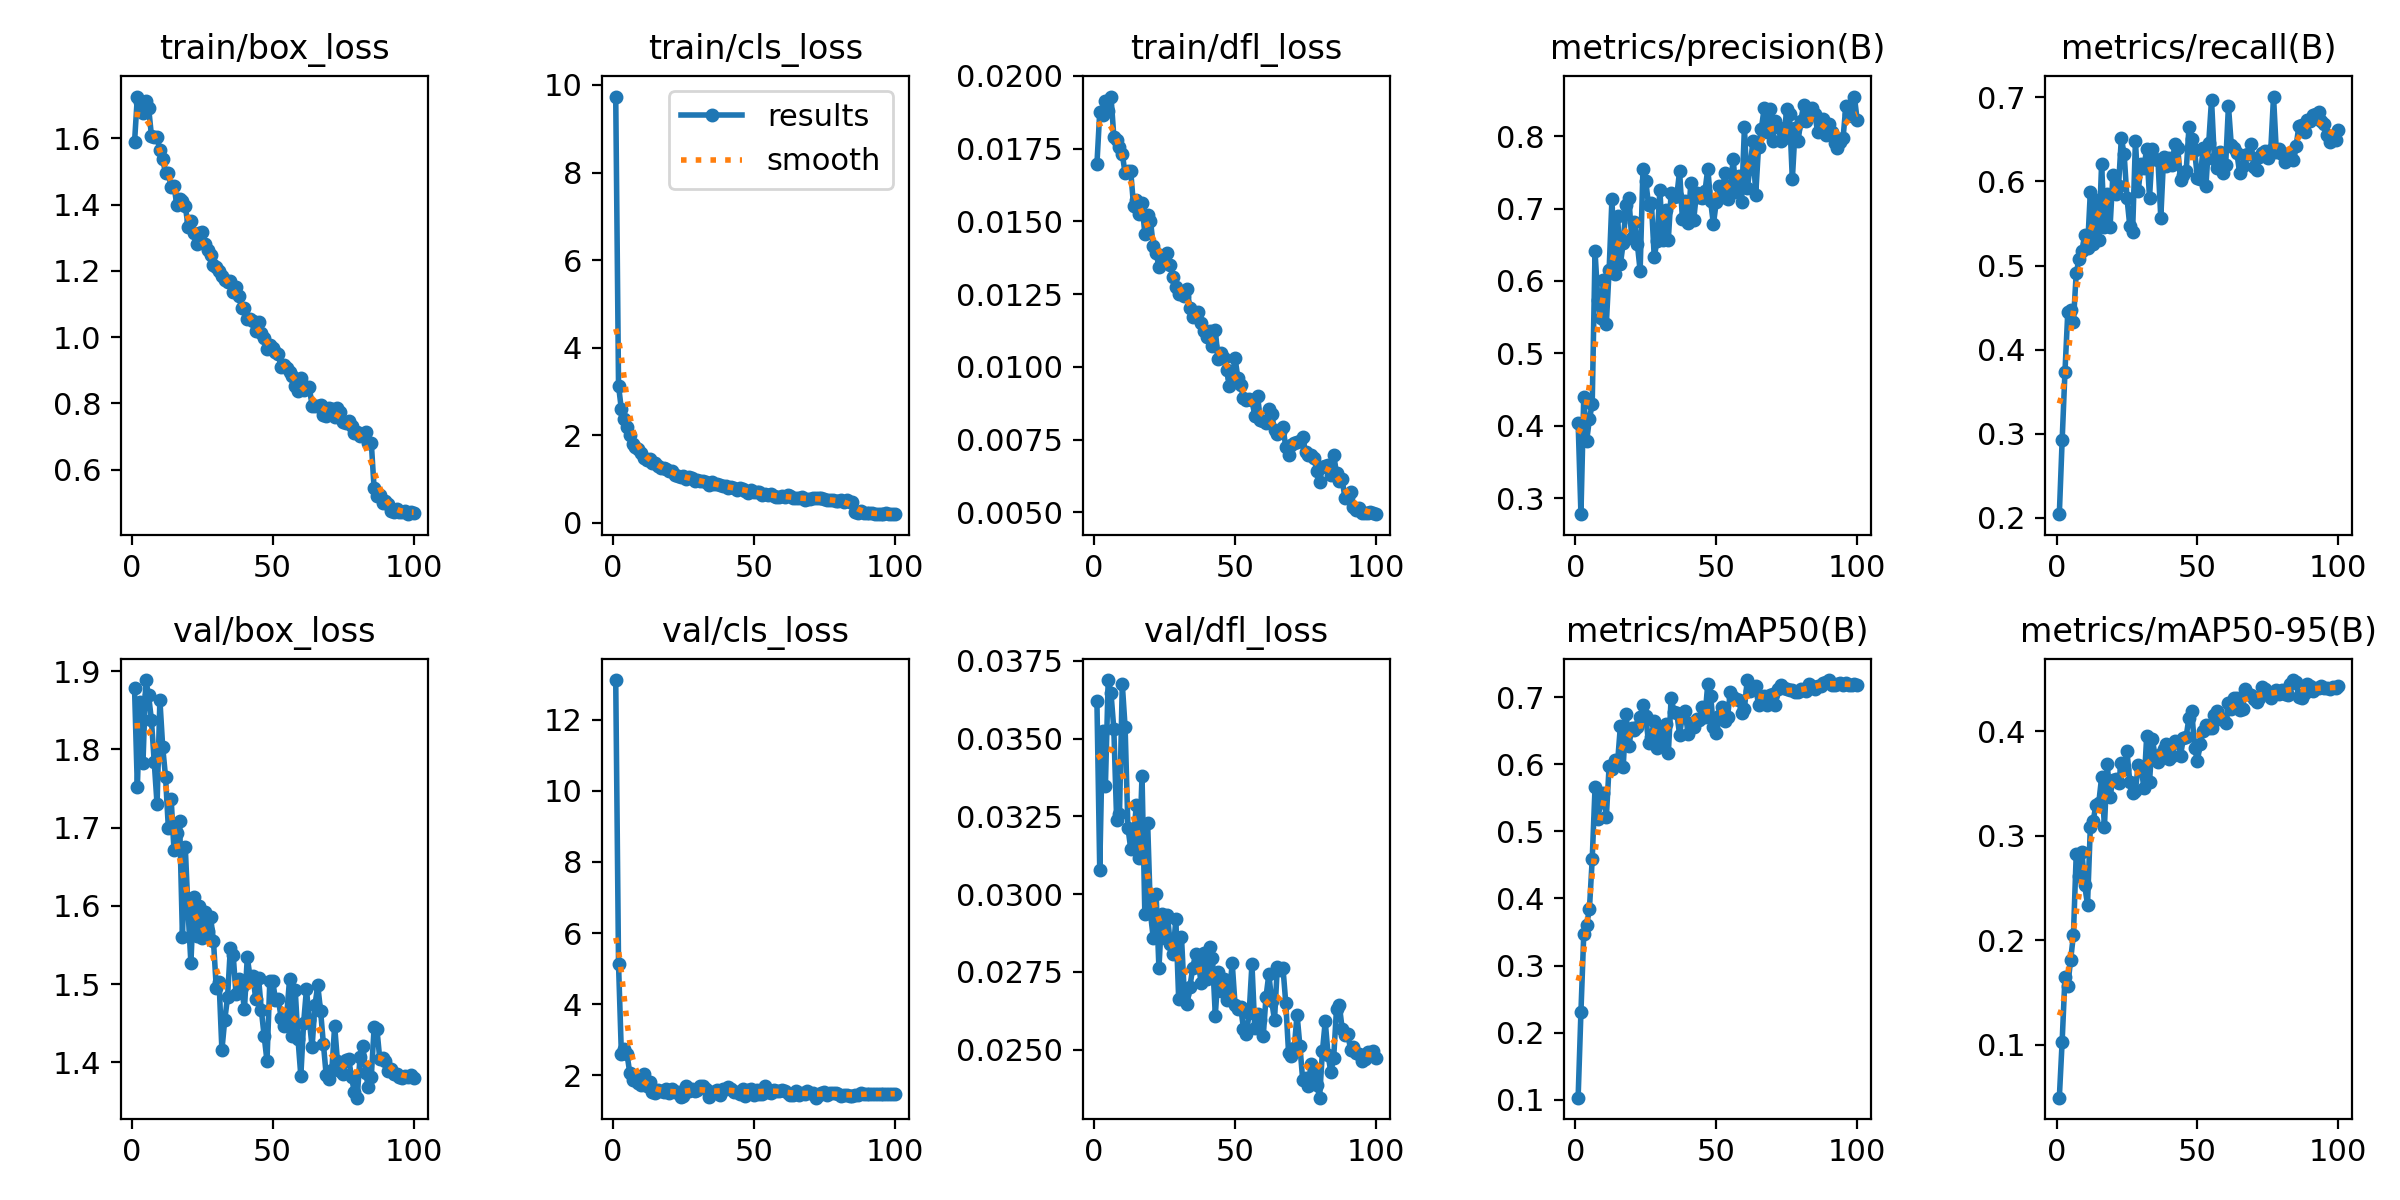

In [17]:
display(Image(filename=os.path.join(small_dir, 'results.png'), width=850))

#### Matriz de Confusão

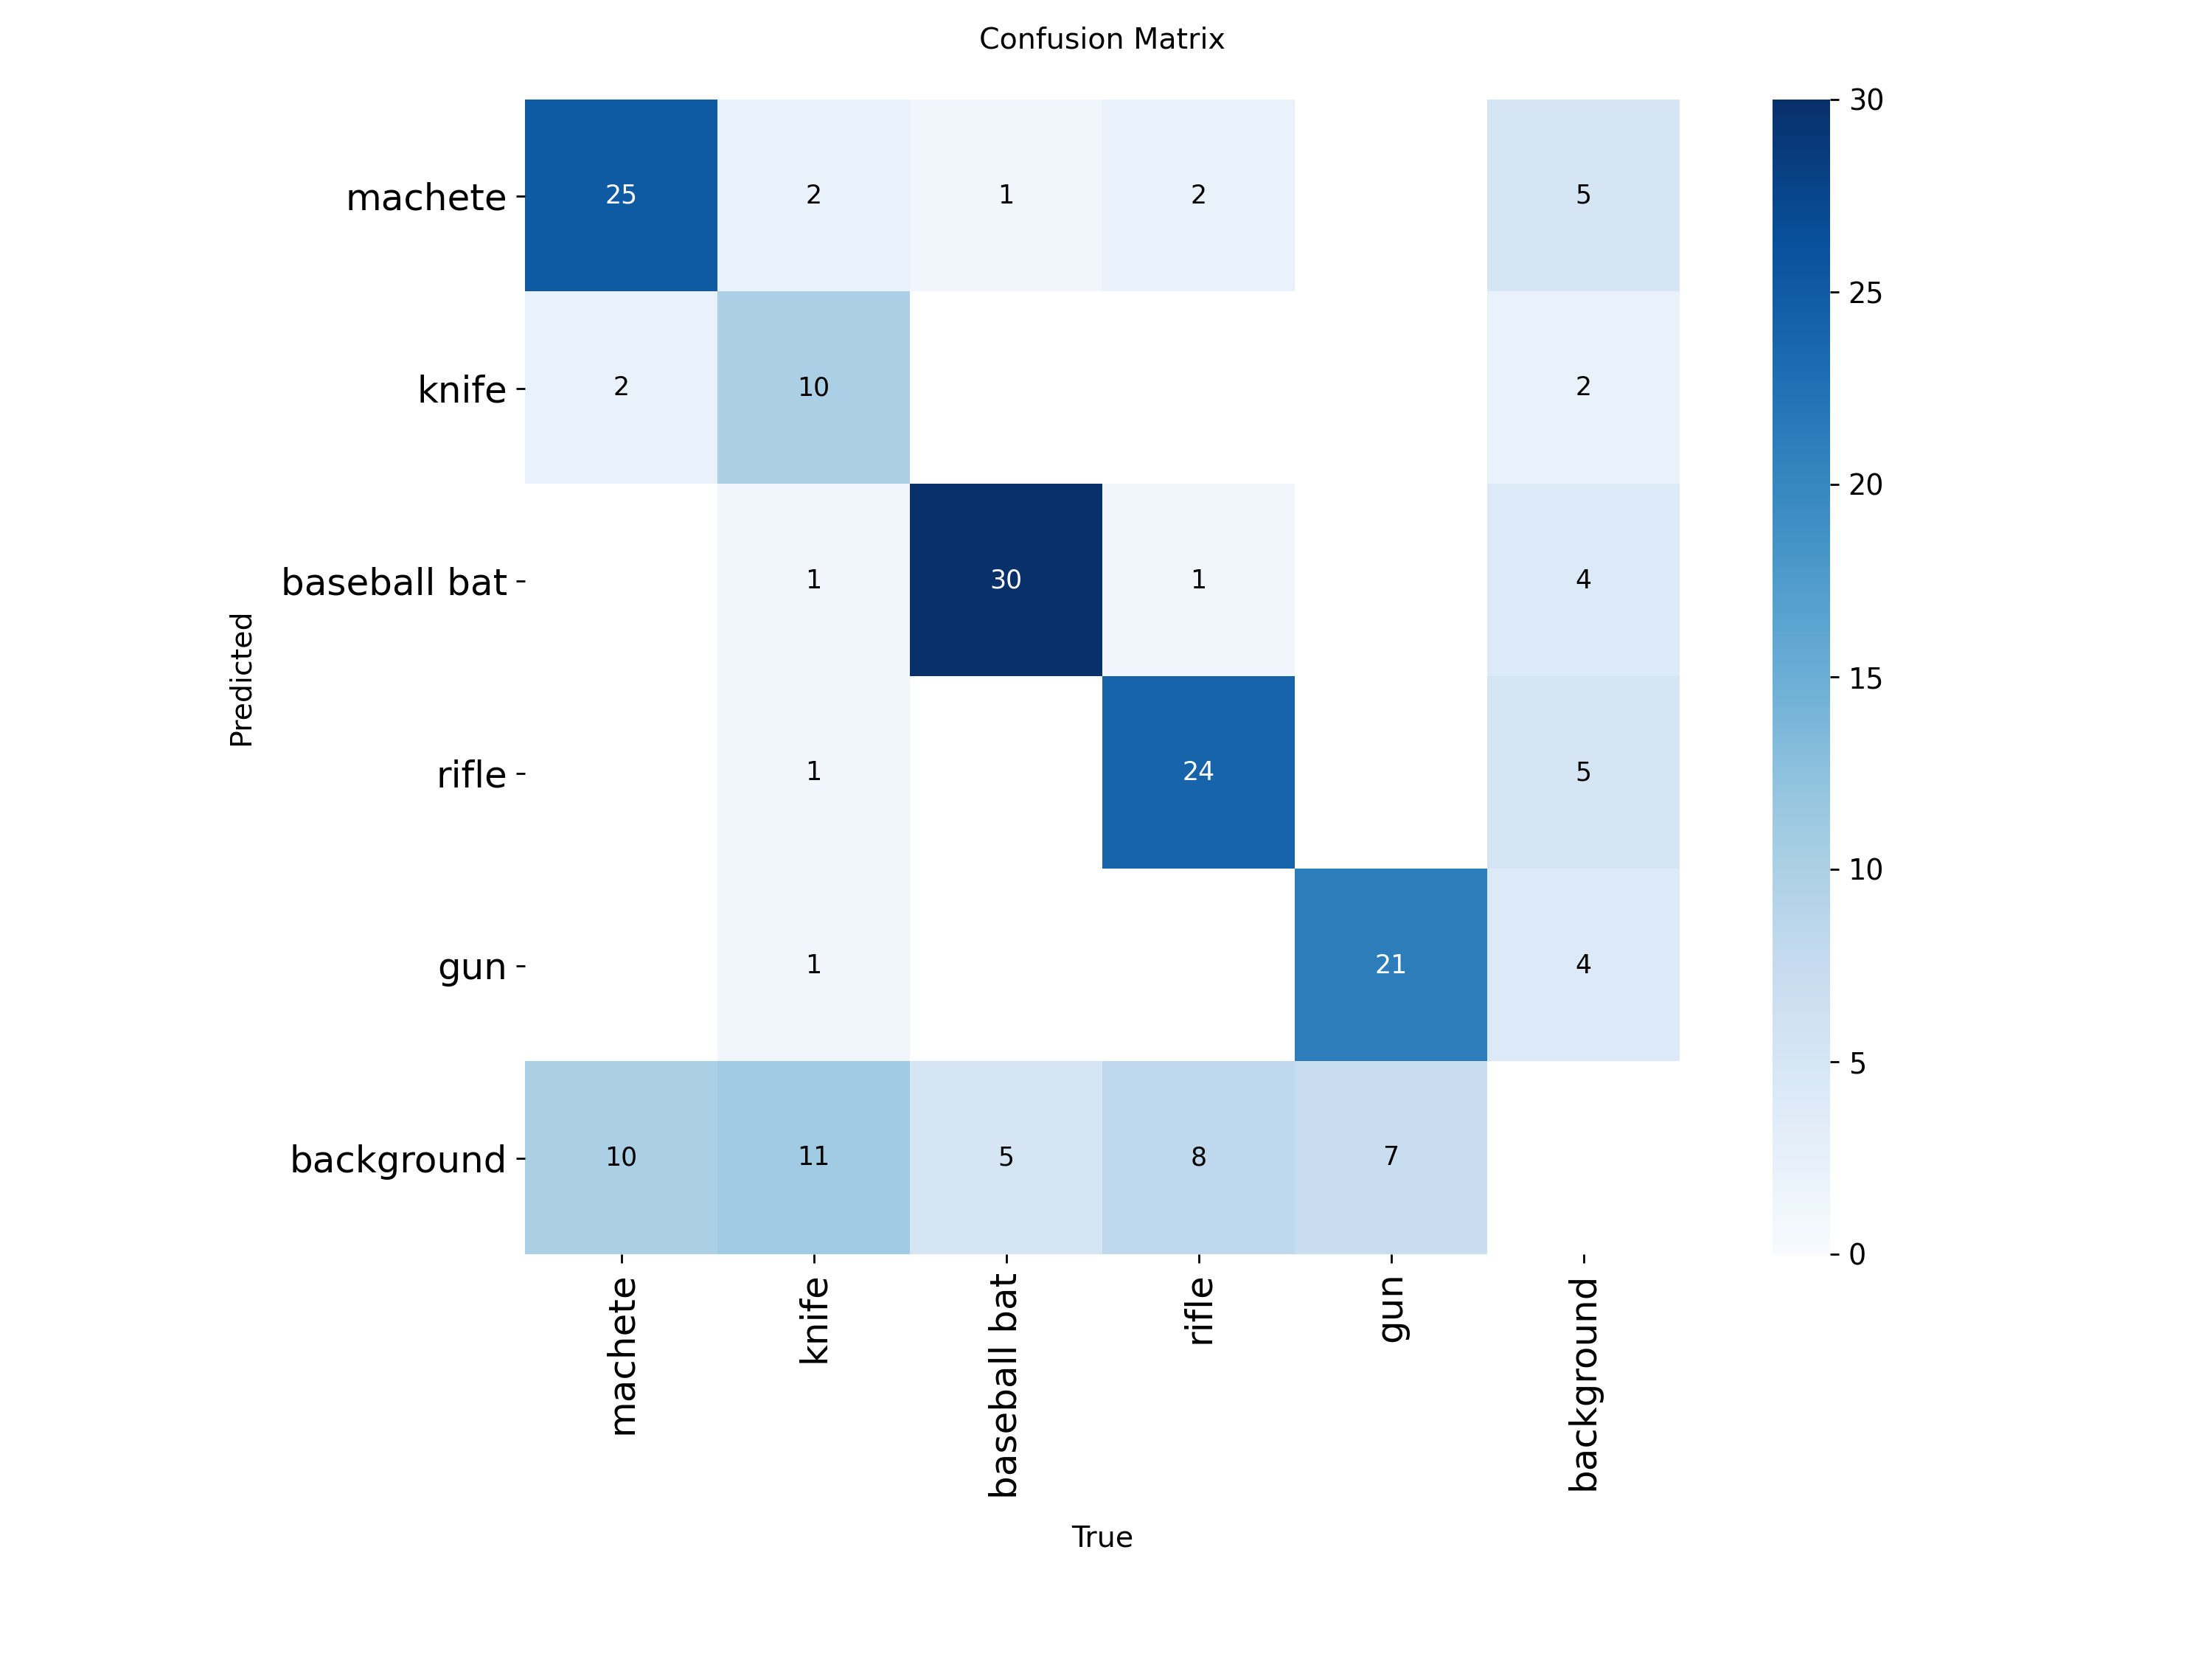

In [18]:
display(Image(filename=os.path.join(small_dir, 'confusion_matrix.png'), width=800))

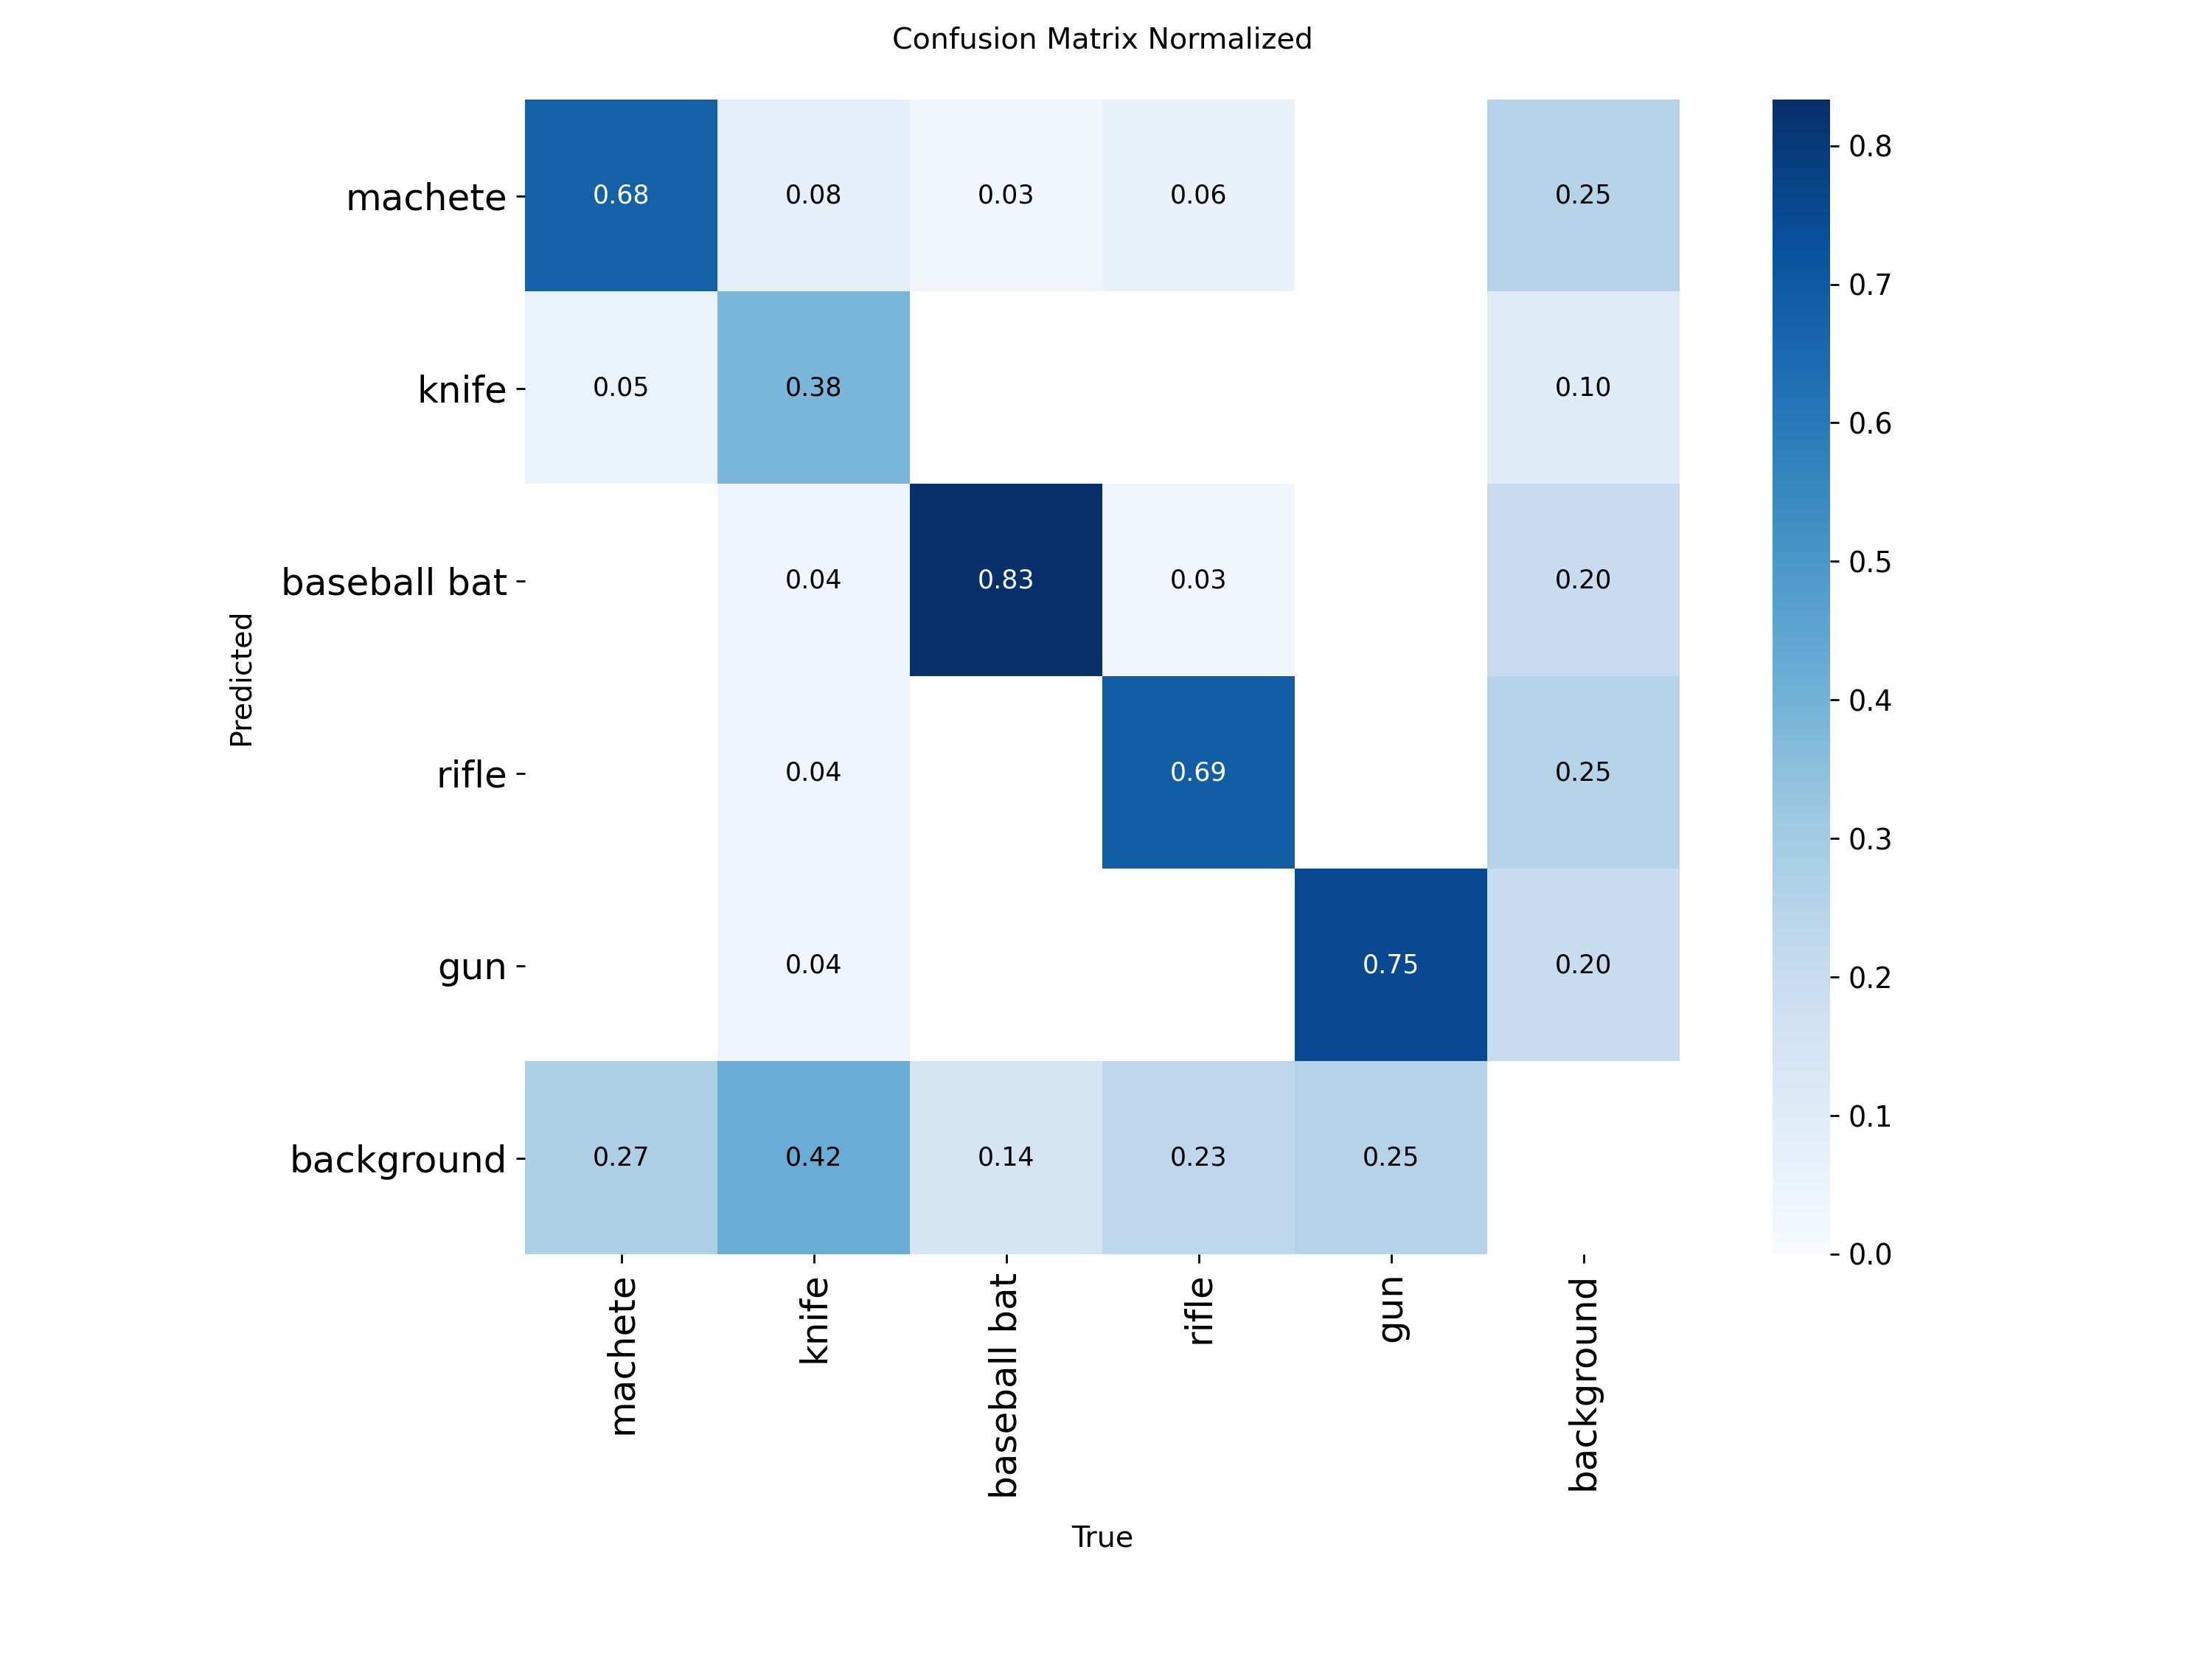

In [19]:
display(Image(filename=os.path.join(small_dir, 'confusion_matrix_normalized.png'), width=800))

#### Curva Precision-Recall

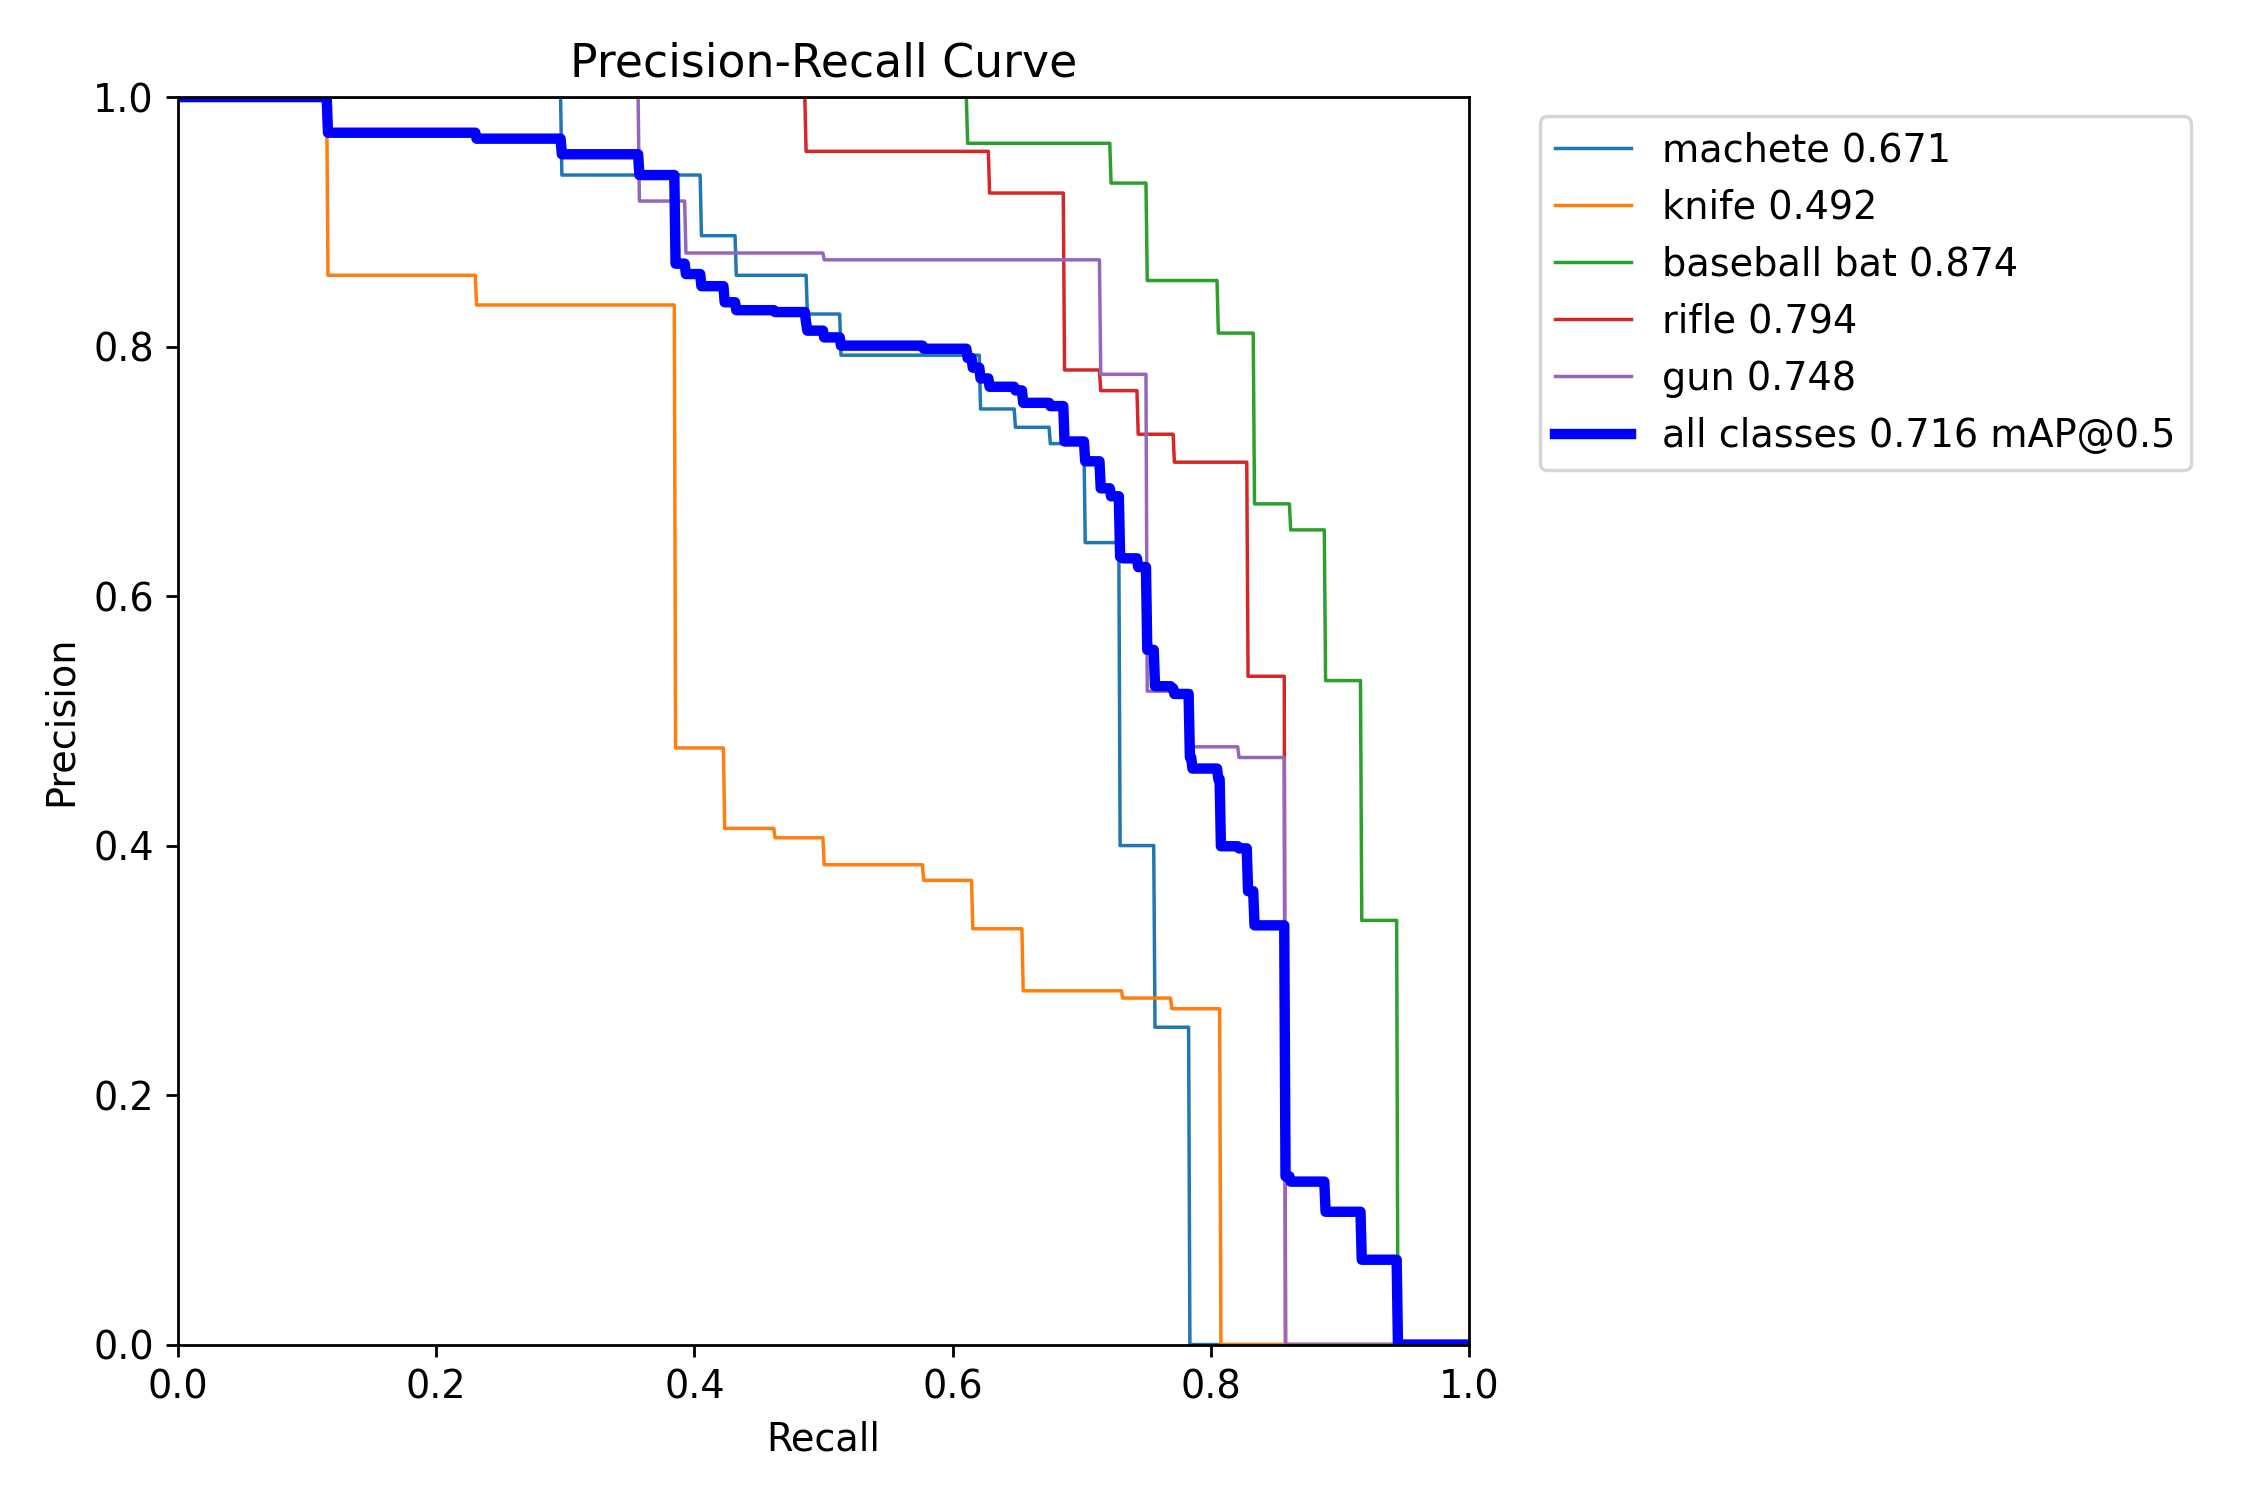

In [20]:
display(Image(filename=os.path.join(small_dir, 'BoxPR_curve.png'), width=800))

## Predição dos Modelos

In [21]:
test_dir = os.path.join(results_dir, 'dataset_subset', 'images', 'test')
test_images = glob.glob(os.path.join(test_dir, '*'))
sample_image = random.choice(test_images)

print(f"Predição na imagem: {os.path.basename(sample_image)}")

pred_nano = yolo26.predict(best_model_path=best_nano, test_path=sample_image)[0]
img_nano = pred_nano.plot()[..., ::-1] # BGR para RGB

pred_small = yolo26.predict(best_model_path=best_small, test_path=sample_image)[0]
img_small = pred_small.plot()[..., ::-1] # BGR para RGB

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].imshow(img_nano)
axes[0].set_title("Modelo NANO", fontsize=18)
axes[0].axis('off')

axes[1].imshow(img_small)
axes[1].set_title("Modelo SMALL", fontsize=18)
axes[1].axis('off')

plt.tight_layout()
plt.show()

Predição na imagem: A7_4c2df2ab-0310.jpg


image 1/1 /opt/topicos/dangerousItems/yolo_dangerous_items/resultados/dataset_subset/images/test/A7_4c2df2ab-0310.jpg: 480x640 1 knife, 17.0ms


Speed: 0.9ms preprocess, 17.0ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)


image 1/1 /opt/topicos/dangerousItems/yolo_dangerous_items/resultados/dataset_subset/images/test/A7_4c2df2ab-0310.jpg: 480x640 1 knife, 15.5ms


Speed: 0.8ms preprocess, 15.5ms inference, 0.2ms postprocess per image at shape (1, 3, 480, 640)


<Figure size 2000x1000 with 2 Axes>

### Referências Úteis

[Docs Train Ultralytics](https://docs.ultralytics.com/modes/train#augmentation-settings-and-hyperparameters)